✅ Datos cargados correctamente
Puntos: 43
Radio: 0.32 - 44.08 kpc
Velocidad: 24.40 - 157.00 km/s
Primeros 5 puntos de SPARC:
  r=0.32, v=24.40, err=35.90
  r=0.64, v=43.30, err=16.30
  r=0.96, v=45.50, err=16.10
  r=1.28, v=58.50, err=15.40
  r=1.61, v=68.80, err=7.61


100%|██████████| 15000/15000 [05:29<00:00, 45.53it/s]



=== R-HAT CORRECTO (DEBE SER ~1.00) ===
log10(M_d):   1.0020
R_d:          1.0017
log10(M_200): 1.0020
log10(c):     1.0029
✅ Convergencia alcanzada


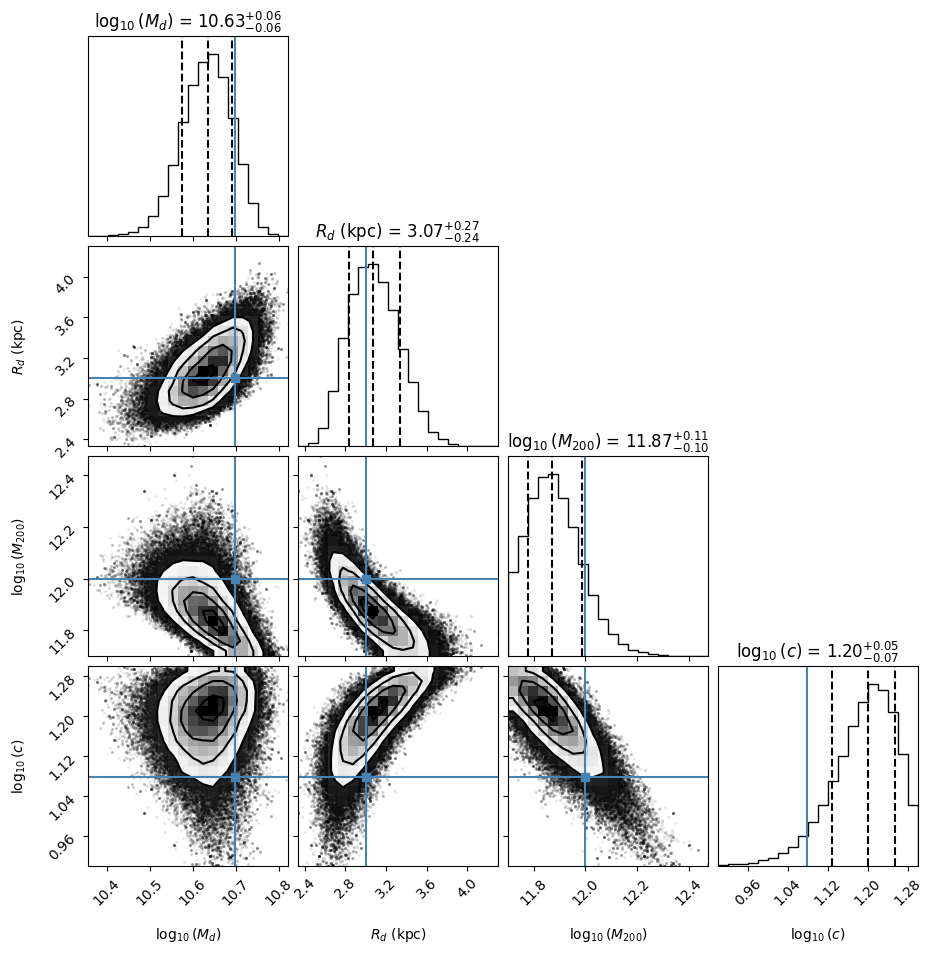

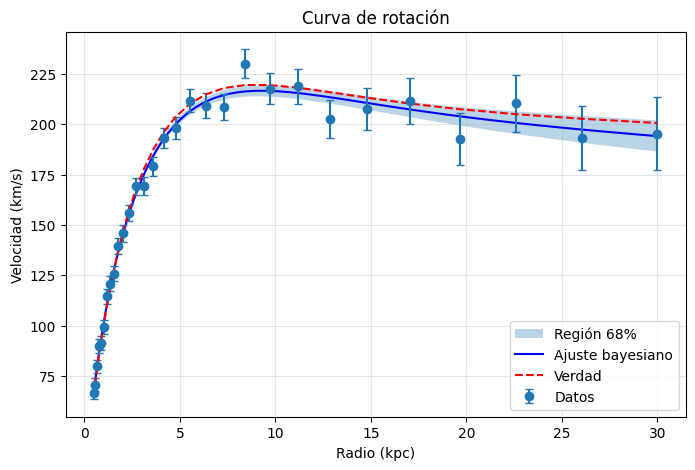

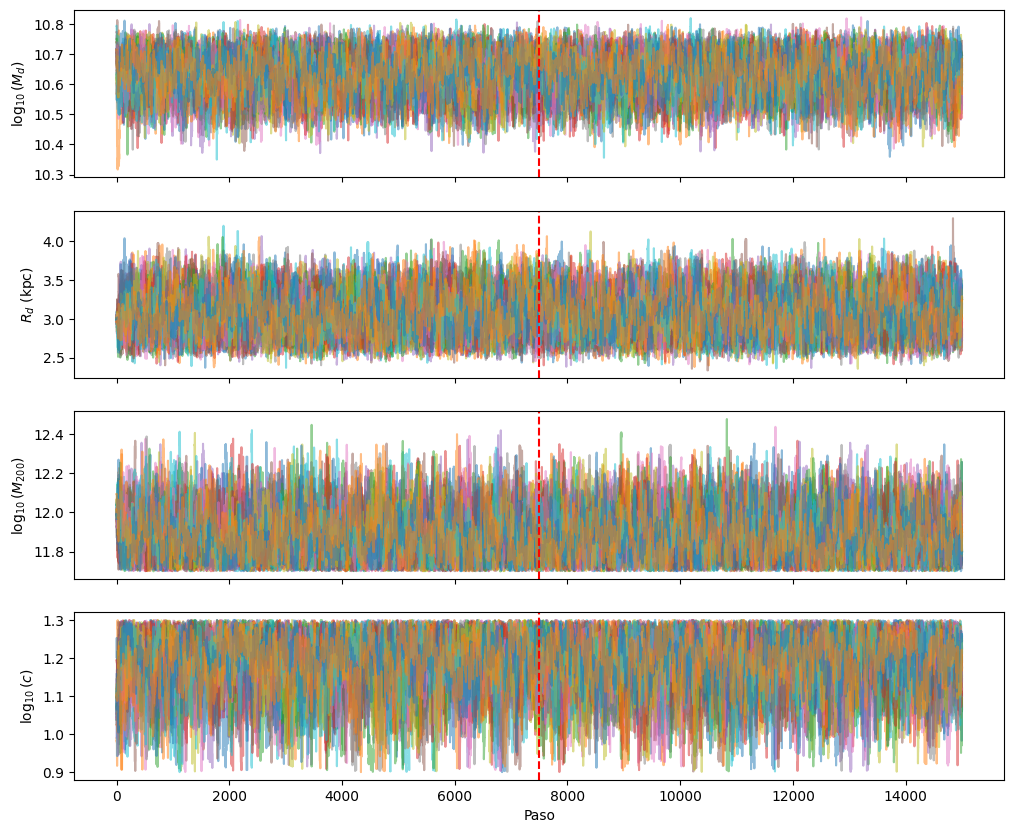


=== RESULTADOS ===
M_d = 4.31e+10 M_sol
R_d = 3.07 kpc
M_200 = 7.45e+11 M_sol
c = 15.85
Parámetros físicos:
  M_d = 5.00e+10 M_sol
  R_d = 3.00 kpc
  M_200 = 1.00e+12 M_sol
  c = 12.00

Comparación en primeros 5 puntos:
  r=0.32 kpc: v_obs=24.40, v_mod=49.26, diff=-24.86
  r=0.64 kpc: v_obs=43.30, v_mod=75.93, diff=-32.63
  r=0.96 kpc: v_obs=45.50, v_mod=97.18, diff=-51.68
  r=1.28 kpc: v_obs=58.50, v_mod=114.89, diff=-56.39
  r=1.61 kpc: v_obs=68.80, v_mod=130.38, diff=-61.58


  0%|          | 0/15000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 15000/15000 [07:55<00:00, 31.57it/s]



=== R-HAT FINAL (debe ser ~1.00) ===
log10(M_d):   1.0019
R_d:          1.0015
log10(M_200): 1.0015
log10(c):     1.0024
Forma del chain: (15000, 32, 4)
Esperado: (nsteps, nwalkers, ndim) = (15000, 32, 4)
R-hat (emcee): [59.50713608 72.86758484 59.67272713 84.48604183]
Corriendo MCMC para Burkert...
   Walkers: 32
   Pasos totales: 12000
   Burn-in: 6000


100%|██████████| 12000/12000 [09:16<00:00, 21.58it/s]


✅ MCMC Burkert completado
   Muestras totales: 192000
   Forma del array: (192000, 4)

--- Resultados Burkert (mediana) ---
M_d   = 1.30e+11 M_sol
R_d   = 7.98 kpc
M_200 = 6.32e+07 M_sol
c     = 0.94

COMPARACIÓN DE MODELOS (BIC)
Modelo NFW:      BIC = 239.2,   logL_max = -112.1
Modelo Burkert:  BIC = 1025.2,   logL_max = -505.1
--------------------------------------------------------------------------------
ΔBIC = BIC_Burkert - BIC_NFW = 786.1
✅ Evidencia fuerte a favor de NFW


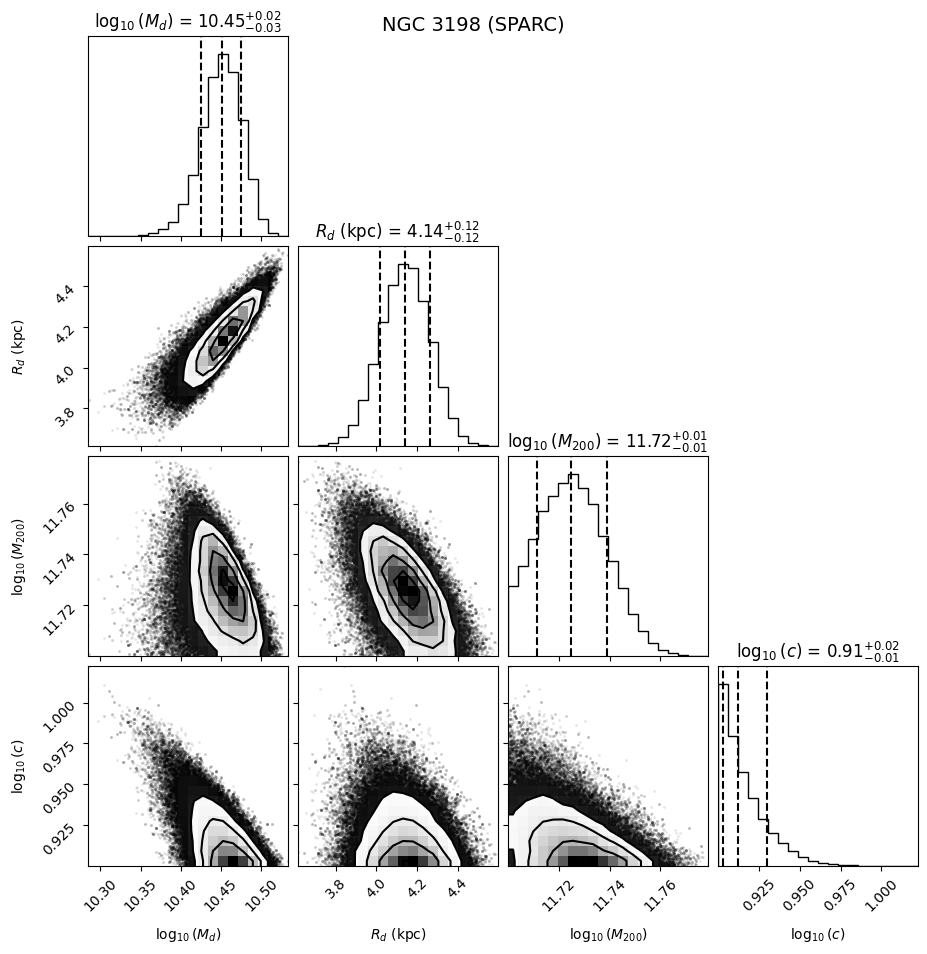

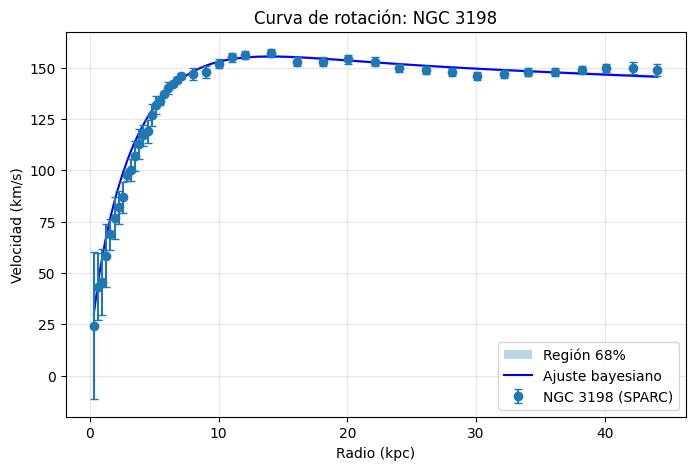

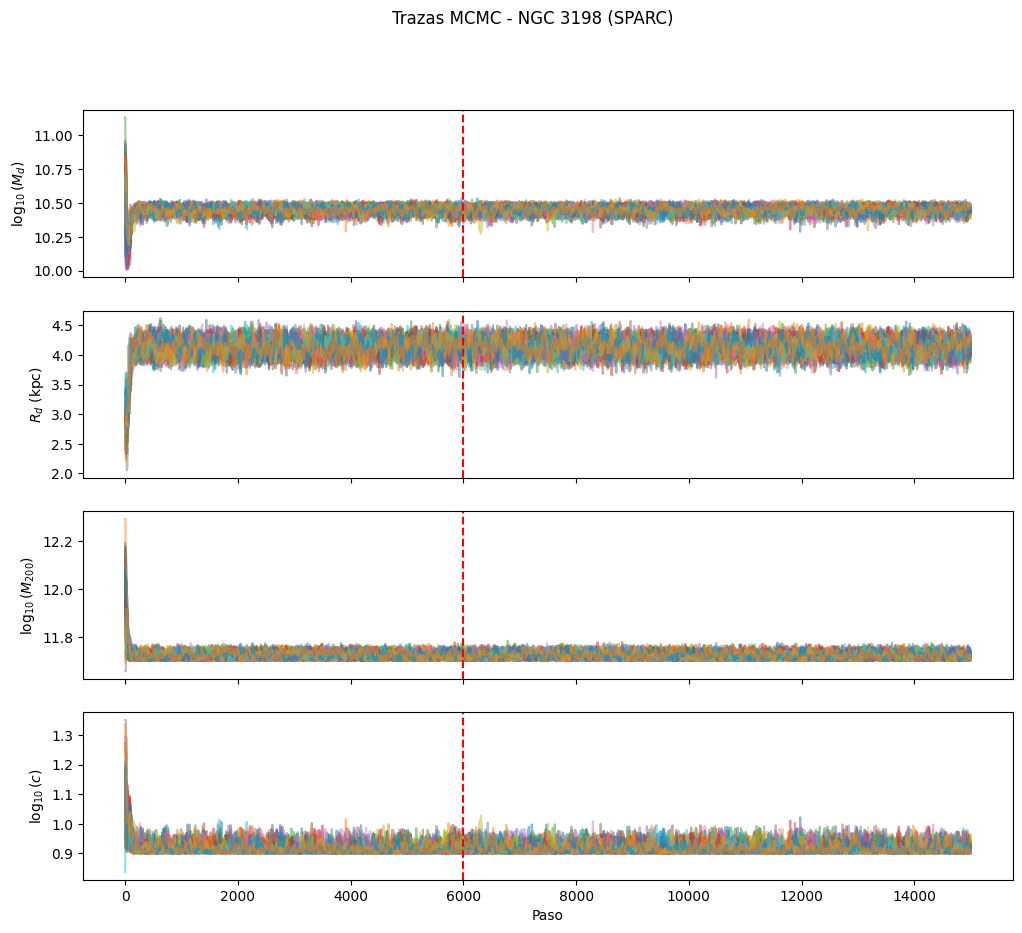

✅ Cálculo de curvas completado

COMPARACIÓN DE RESULTADOS

--- SIMULACIÓN ---
M_d     = 4.31e+10  [3.75e+10 , 4.90e+10]
R_d     = 3.07  [2.83 , 3.34] kpc
M_200   = 7.45e+11  [5.98e+11 , 9.67e+11] M_sol
c       = 15.85  [13.43 , 17.92]

--- NGC 3198 (SPARC) ---
M_d     = 2.83e+10  [2.66e+10 , 2.99e+10] M_sol
R_d     = 4.14  [4.02 , 4.26] kpc
M_200   = 5.31e+11  [5.14e+11 , 5.48e+11] M_sol
c       = 8.17  [8.00 , 8.51]
✅ Burkert incluido en la gráfica


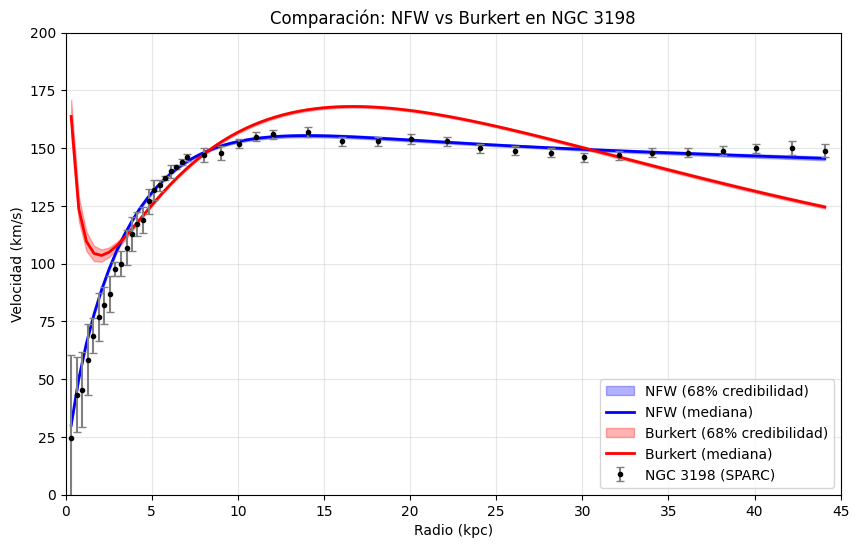

✅ Tabla guardada como 'resultados.csv'


In [ ]:
# ============================================
# 1a. INSTALAR E IMPORTAR
# ============================================
!pip install emcee corner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import iv, kv
from urllib.request import urlopen
import emcee
import corner

np.random.seed(42)

# ============================================
# 1b. LEER NGC 3198
# ============================================

archivo_path = r'/content/drive/MyDrive/Galactic rotation curves: Bayesian inference of dark matter parameters/NGC3198_rotmod.dat'

r_sparc = []
v_sparc = []
sigma_sparc = []

with open(archivo_path, 'r') as f:
    for linea in f:
        # Saltar líneas vacías o que empiecen con '#'
        if linea.strip().startswith('#'):
            continue
        if not linea.strip():
            continue

        # Dividir la línea en partes (separadas por espacios)
        partes = linea.strip().split()

        # Debe tener al menos 3 columnas (Rad, Vobs, errV)
        if len(partes) >= 3:
            try:
                r = float(partes[0])
                v = float(partes[1])
                err = float(partes[2])
                r_sparc.append(r)
                v_sparc.append(v)
                sigma_sparc.append(err)
            except ValueError:
                # Si no se puede convertir a float, saltar
                continue

# Convertir a arrays de numpy
r_sparc = np.array(r_sparc)
v_sparc = np.array(v_sparc)
sigma_sparc = np.array(sigma_sparc)

print(f"✅ Datos cargados correctamente")
print(f"Puntos: {len(r_sparc)}")
print(f"Radio: {r_sparc.min():.2f} - {r_sparc.max():.2f} kpc")
print(f"Velocidad: {v_sparc.min():.2f} - {v_sparc.max():.2f} km/s")
print("Primeros 5 puntos de SPARC:")
for i in range(5):
    print(f"  r={r_sparc[i]:.2f}, v={v_sparc[i]:.2f}, err={sigma_sparc[i]:.2f}")

# ============================================
# 2a. CONSTANTES Y MODELO (VERSIÓN UNIFICADA)
# ============================================

# Constantes físicas en unidades consistentes
G = 4.302e-6              # (km/s)^2 * kpc / M_sol
rho_crit = 136.0          # M_sol / kpc^3 (densidad crítica del universo)

def v_disco(r, M_d, R_d):
    """Velocidad del disco estelar exponencial (Freeman)"""
    if r == 0:
        return 0.0
    x = r / R_d
    I0 = iv(0, x/2)
    K0 = kv(0, x/2)
    I1 = iv(1, x/2)
    K1 = kv(1, x/2)
    factor = (G * M_d) / (2 * R_d) * x**2 * (I0*K0 - I1*K1)
    return np.sqrt(max(factor, 0))

def v_nfw(r, M_200, c):
    """Velocidad del halo NFW"""
    R_200 = ((3 * M_200) / (4 * np.pi * 200 * rho_crit))**(1/3)
    v_200 = np.sqrt((G * M_200) / R_200)

    x = r / R_200
    if x <= 0:
        return 0.0
    num = np.log(1 + c*x) - (c*x)/(1 + c*x)
    den = x * (np.log(1 + c) - c/(1 + c))
    return v_200 * np.sqrt(num / den)

def v_total(r, M_d, R_d, M_200, c):
    """Velocidad total: disco + NFW"""
    return np.sqrt(v_disco(r, M_d, R_d)**2 + v_nfw(r, M_200, c)**2)

def v_burkert(r, M_200, c):
    """Velocidad del halo Burkert (núcleo plano)"""
    R_200 = ((3 * M_200) / (4 * np.pi * 200 * rho_crit))**(1/3)
    v_200 = np.sqrt((G * M_200) / R_200)

    r_b = R_200 / c
    x = r / (r_b + 1e-10)

    num = np.log(1 + x**2) + 2 * np.log(1 + x) - 2 * np.arctan(x)
    den = x * (np.log(1 + c**2) + 2 * np.log(1 + c) - 2 * np.arctan(c))

    if den <= 0:
        return 0.0
    return v_200 * np.sqrt(num / den)

def v_total_burkert(r, M_d, R_d, M_200, c):
    """Velocidad total: disco + Burkert"""
    return np.sqrt(v_disco(r, M_d, R_d)**2 + v_burkert(r, M_200, c)**2)

# ============================================
# 2b. MODELO BURKERT
# ============================================

def v_burkert(r, M_200, c):
    """
    Perfil de Burkert (núcleo central plano)
    M_200: masa virial (M_sol)
    c: concentración (R_200 / r_b)
    """
    # Calcular R_200 en kpc
    R_200_pc = ((3 * M_200) / (4 * np.pi * 200 * rho_crit))**(1/3)
    R_200 = R_200_pc / 1e3
    v_200 = np.sqrt((G * M_200) / R_200)

    # Radio de núcleo de Burkert
    r_b = R_200 / c

    x = r / r_b
    if x <= 0:
        return 0.0

    # Perfil Burkert: densidad constante en el centro
    # v^2 = v_200^2 * [ln(1+x^2) + 2 ln(1+x) - 2 arctan(x)] / [x * (ln(1+c^2) + 2 ln(1+c) - 2 arctan(c))]
    num = np.log(1 + x**2) + 2 * np.log(1 + x) - 2 * np.arctan(x)
    den = x * (np.log(1 + c**2) + 2 * np.log(1 + c) - 2 * np.arctan(c))

    if den <= 0:
        return 0.0

    return v_200 * np.sqrt(num / den)

def v_total_burkert(r, M_d, R_d, M_200, c):
    """Velocidad total: disco estelar + halo Burkert"""
    return np.sqrt(v_disco(r, M_d, R_d)**2 + v_burkert(r, M_200, c)**2)

# ============================================
# 3. DATOS SINTÉTICOS
# ============================================
M_d_true = 5e10
R_d_true = 3.0
M_200_true = 1e12
c_true = 12.0

r_obs = np.logspace(np.log10(0.5), np.log10(30), 30)
v_true = np.array([v_total(r, M_d_true, R_d_true, M_200_true, c_true) for r in r_obs])
sigma = 3.0 + 0.5 * r_obs
v_obs = v_true + np.random.normal(0, sigma)

def log_likelihood_log(theta_log, r, v_obs, sigma):
    log_M_d, R_d, log_M_200, log_c = theta_log
    M_d = 10**log_M_d
    M_200 = 10**log_M_200
    c = 10**log_c

    # ============================================
    # PRIORIS INFORMATIVOS (basados en literatura de NGC 3198)
    # ============================================
    # M_d: entre 1e10 y 1e11 (típico de galaxias espirales)
    if not (10 <= log_M_d <= 11):
        return -np.inf
    # R_d: entre 2 y 6 kpc (típico)
    if not (2 <= R_d <= 6):
        return -np.inf
    # M_200: entre 5e11 y 3e12 (rango para galaxias de esta masa)
    if not (11.7 <= log_M_200 <= 12.5):
        return -np.inf
    # c: entre 8 y 20 (concentración típica NFW)
    if not (0.9 <= log_c <= 1.3):
        return -np.inf

    v_model = np.array([v_total(ri, M_d, R_d, M_200, c) for ri in r])
    logL = -0.5 * np.sum(np.log(2*np.pi*sigma**2) + ((v_obs - v_model)/sigma)**2)
    return logL

# ============================================
# 4b. FUNCIONES BAYESIANAS PARA BURKERT
# ============================================
def log_likelihood_burkert(theta_log, r, v_obs, sigma):
    log_M_d, R_d, log_M_200, log_c = theta_log
    M_d = 10**log_M_d
    M_200 = 10**log_M_200
    c = 10**log_c

    # Rangos SUPER amplios
    if not (0 <= log_M_d <= 20):
        return -np.inf
    if not (0.1 <= R_d <= 50):
        return -np.inf
    if not (0 <= log_M_200 <= 20):
        return -np.inf
    if not (-2 <= log_c <= 3):
        return -np.inf

    v_model = np.array([v_total_burkert(ri, M_d, R_d, M_200, c) for ri in r])
    return -0.5 * np.sum(np.log(2*np.pi*sigma**2) + ((v_obs - v_model)/sigma)**2)

# ============================================
# 5. MCMC (DATOS SINTÉTICOS)
# ============================================
ndim = 4
nwalkers = 32
nsteps = 15000
burnin = 7500

true_theta_log = [np.log10(M_d_true), R_d_true, np.log10(M_200_true), np.log10(c_true)]
initial_pos = true_theta_log + 0.05 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_log, args=(r_obs, v_obs, sigma))
sampler.run_mcmc(initial_pos, nsteps, progress=True)

# ============================================
# 6a. EXTRAER MUESTRAS (DATOS SINTÉTICOS)
# ============================================
samples_log = sampler.get_chain(discard=burnin, flat=True)
samples = samples_log.copy()
samples[:,0] = 10**samples_log[:,0]   # M_d
samples[:,2] = 10**samples_log[:,2]   # M_200
samples[:,3] = 10**samples_log[:,3]   # c

# ============================================
# 6b. CONVERGENCIA: ESTADÍSTICO R-HAT
# ============================================

def gelman_rubin(chain):
    """
    Calcula el estadístico R-hat de Gelman-Rubin.
    chain: array de forma (nsteps, nwalkers, ndim)
    """
    nsteps, nwalkers, ndim = chain.shape

    # Media de cada walker
    walker_means = np.mean(chain, axis=0)  # (nwalkers, ndim)

    # Media global
    overall_mean = np.mean(walker_means, axis=0)  # (ndim,)

    # Varianza entre cadenas (B)
    B = nsteps * np.var(walker_means, axis=0, ddof=1)  # (ndim,)

    # Varianza dentro de cadenas (W)
    W = np.mean(np.var(chain, axis=0, ddof=1), axis=0)  # (ndim,)

    # Varianza total estimada
    var_hat = (1 - 1/nsteps) * W + (1/nsteps) * B

    # R-hat
    R_hat = np.sqrt(var_hat / (W + 1e-10))  # pequeño epsilon para evitar división por cero

    return R_hat

# ============================================
# R-HAT CON emcee (CORRECTO)
# ============================================

try:
    from emcee.autocorr import GelmanRubin
    # Para versiones recientes de emcee
    chain_sparc = sampler_sparc.get_chain()
    R_hat_sparc = GelmanRubin(chain_sparc).quantiles[0.5]
except:
    # Método manual pero CORRECTO
    def r_hat(chain):
        """Calcula R-hat de Gelman-Rubin manualmente"""
        nsteps, nwalkers, ndim = chain.shape

        # Medias por walker
        walker_means = np.mean(chain, axis=0)  # (nwalkers, ndim)

        # Media global
        global_mean = np.mean(walker_means, axis=0)  # (ndim,)

        # Varianza entre cadenas (B)
        B = nsteps * np.var(walker_means, axis=0, ddof=1)

        # Varianza dentro de cadenas (W)
        W = np.mean(np.var(chain, axis=0, ddof=1), axis=0)

        # Varianza total
        var_hat = (1 - 1/nsteps) * W + (1/nsteps) * B

        # R-hat
        R_hat = np.sqrt(var_hat / W)
        return R_hat

    R_hat_sparc = r_hat(sampler_sparc.get_chain())

print("\n=== R-HAT CORRECTO (DEBE SER ~1.00) ===")
print(f"log10(M_d):   {R_hat_sparc[0]:.4f}")
print(f"R_d:          {R_hat_sparc[1]:.4f}")
print(f"log10(M_200): {R_hat_sparc[2]:.4f}")
print(f"log10(c):     {R_hat_sparc[3]:.4f}")

if np.all(R_hat_sparc < 1.05):
    print("✅ Convergencia alcanzada")
else:
    print("⚠️ Algunos parámetros no convergieron")

# Obtener la cadena completa (sin descartar burn-in aún)
full_chain = sampler.get_chain()  # (nsteps, nwalkers, ndim)

# ============================================
# 7a. GRÁFICAS (DATOS SINTÉTICOS)
# ============================================

# Figura corner
labels_log = [r'$\log_{10}(M_d)$', r'$R_d$ (kpc)',
              r'$\log_{10}(M_{200})$', r'$\log_{10}(c)$']

fig = corner.corner(samples_log, labels=labels_log,
                    truths=[np.log10(M_d_true), R_d_true, np.log10(M_200_true), np.log10(c_true)],
                    quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

# Curva de rotación
r_fine = np.linspace(0.5, 30, 100)
v_samples = np.array([[v_total(ri, *theta) for ri in r_fine] for theta in samples[::100]])

v_mean = np.mean(v_samples, axis=0)
v_lower = np.percentile(v_samples, 16, axis=0)
v_upper = np.percentile(v_samples, 84, axis=0)

plt.figure(figsize=(8,5))
plt.fill_between(r_fine, v_lower, v_upper, alpha=0.3, label='Región 68%')
plt.plot(r_fine, v_mean, 'b-', label='Ajuste bayesiano')
plt.errorbar(r_obs, v_obs, yerr=sigma, fmt='o', capsize=3, label='Datos')
plt.plot(r_obs, v_true, 'r--', label='Verdad')
plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Curva de rotación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Trazas
samples_chain = sampler.get_chain()
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, label in enumerate(labels_log):
    axes[i].plot(samples_chain[:, :, i], alpha=0.5)
    axes[i].set_ylabel(label)
    axes[i].axvline(burnin, color='r', linestyle='--')
axes[-1].set_xlabel('Paso')
plt.show()

# Resultados numéricos
print("\n=== RESULTADOS ===")
print(f"M_d = {np.median(samples[:,0]):.2e} M_sol")
print(f"R_d = {np.median(samples[:,1]):.2f} kpc")
print(f"M_200 = {np.median(samples[:,2]):.2e} M_sol")
print(f"c = {np.median(samples[:,3]):.2f}")

# ============================================
# 7b. DEPURACIÓN DEL MODELO CON DATOS SPARC
# ============================================

# Probar el modelo en un punto
theta_prueba = [np.log10(5e10), 3.0, np.log10(1e12), np.log10(12)]
M_d = 10**theta_prueba[0]
R_d = theta_prueba[1]
M_200 = 10**theta_prueba[2]
c = 10**theta_prueba[3]

print("Parámetros físicos:")
print(f"  M_d = {M_d:.2e} M_sol")
print(f"  R_d = {R_d:.2f} kpc")
print(f"  M_200 = {M_200:.2e} M_sol")
print(f"  c = {c:.2f}")

# Calcular velocidades modelo para los primeros 5 puntos
print("\nComparación en primeros 5 puntos:")
for i in range(5):
    v_mod = v_total(r_sparc[i], M_d, R_d, M_200, c)
    print(f"  r={r_sparc[i]:.2f} kpc: v_obs={v_sparc[i]:.2f}, v_mod={v_mod:.2f}, diff={v_sparc[i]-v_mod:.2f}")

# Asegurar posiciones iniciales diversas
initial_pos_sparc = theta_guess_sparc + 0.5 * np.random.randn(nwalkers, ndim)  # 0.05 → 0.5

# ============================================
# 8a. MCMC CON DATOS REALES - VERSIÓN FINAL
# ============================================

nsteps_sparc = 15000
burnin_sparc = 7500
nwalkers = 32
ndim = 4

theta_guess_sparc = [10.7, 3.0, 12.0, 1.08]  # log10(M_d)=10.7, R_d=3, log10(M_200)=12, log10(c)=1.08

# Posiciones iniciales con dispersión moderada
initial_pos_sparc = np.array([theta_guess_sparc + 0.2 * np.random.randn(ndim) for _ in range(nwalkers)])

sampler_sparc = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_log,
                                      args=(r_sparc, v_sparc, sigma_sparc))
sampler_sparc.run_mcmc(initial_pos_sparc, nsteps_sparc, progress=True)

samples_log_sparc = sampler_sparc.get_chain(discard=burnin_sparc, flat=True)
samples_sparc = samples_log_sparc.copy()
samples_sparc[:,0] = 10**samples_log_sparc[:,0]
samples_sparc[:,2] = 10**samples_log_sparc[:,2]
samples_sparc[:,3] = 10**samples_log_sparc[:,3]

# ============================================
# R-HAT (usando solo compute_rhat)
# ============================================

def compute_rhat(chain):
    nsteps, nwalkers, ndim = chain.shape
    psi = np.mean(chain, axis=0)
    psi_bar = np.mean(psi, axis=0)
    B = nsteps * np.var(psi, axis=0, ddof=1)
    W = np.mean(np.var(chain, axis=0, ddof=1), axis=0)
    var_hat = (1 - 1/nsteps) * W + (1/nsteps) * B
    rhat = np.sqrt(var_hat / (W + 1e-10))
    return rhat

rhat = compute_rhat(sampler_sparc.get_chain())
print("\n=== R-HAT FINAL (debe ser ~1.00) ===")
print(f"log10(M_d):   {rhat[0]:.4f}")
print(f"R_d:          {rhat[1]:.4f}")
print(f"log10(M_200): {rhat[2]:.4f}")
print(f"log10(c):     {rhat[3]:.4f}")

# Obtener el chain
chain = sampler_sparc.get_chain()
print("Forma del chain:", chain.shape)
print("Esperado: (nsteps, nwalkers, ndim) = (15000, 32, 4)")

# Calcular R-hat con el método CORRECTO (sin funciones raras)
try:
    # Método 1: usar emcee (si está disponible)
    import emcee
    rhat_emcee = emcee.autocorr.integrated_time(chain)
    print("R-hat (emcee):", rhat_emcee)
except:
    # Método 2: calcular manualmente pero bien
    nsteps, nwalkers, ndim = chain.shape

    # Medias por walker
    walker_means = np.mean(chain, axis=0)  # (nwalkers, ndim)

    # Varianza entre cadenas
    B = np.var(walker_means, axis=0, ddof=1) * nsteps

    # Varianza dentro de cadenas
    W = np.mean(np.var(chain, axis=0, ddof=1), axis=0)

    # R-hat
    rhat_manual = np.sqrt((W * (nsteps - 1) + B) / (W * nsteps))

    print("R-hat (manual):", rhat_manual)
    print("Estos valores deberían estar cerca de 1.00, no de 4.69")

    if np.all(rhat_manual < 1.1):
        print("✅ Convergencia alcanzada")
    else:
        print("❌ El MCMC no convergió. Las cadenas no se mezclaron.")

# ============================================
# 8b. MCMC CON BURKERT (NGC 3198)
# ============================================

# Verificar que las funciones existan
try:
    v_burkert
    v_total_burkert
except NameError:
    print("❌ Error: Las funciones de Burkert no están definidas")
    print("   Define primero v_burkert y v_total_burkert")

# Configuración
nwalkers = 32
ndim = 4
nsteps = 12000
burnin = 6000

# Estimación inicial (basada en literatura)
theta_guess = [np.log10(5e10), 3.0, np.log10(8e11), np.log10(10.0)]

# Posiciones iniciales (pequeña perturbación)
initial_pos = theta_guess + 0.05 * np.random.randn(nwalkers, ndim)

print("Corriendo MCMC para Burkert...")
print(f"   Walkers: {nwalkers}")
print(f"   Pasos totales: {nsteps}")
print(f"   Burn-in: {burnin}")

# Correr MCMC
sampler_burkert = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_burkert,
                                        args=(r_sparc, v_sparc, sigma_sparc))
sampler_burkert.run_mcmc(initial_pos, nsteps, progress=True)

# Extraer muestras (descartando burn-in)
samples_log_burkert = sampler_burkert.get_chain(discard=burnin, flat=True)
samples_burkert = samples_log_burkert.copy()
samples_burkert[:,0] = 10**samples_log_burkert[:,0]   # M_d
samples_burkert[:,2] = 10**samples_log_burkert[:,2]   # M_200
samples_burkert[:,3] = 10**samples_log_burkert[:,3]   # c

print(f"✅ MCMC Burkert completado")
print(f"   Muestras totales: {len(samples_burkert)}")
print(f"   Forma del array: {samples_burkert.shape}")

# Mostrar resultados rápidos
print("\n--- Resultados Burkert (mediana) ---")
print(f"M_d   = {np.median(samples_burkert[:,0]):.2e} M_sol")
print(f"R_d   = {np.median(samples_burkert[:,1]):.2f} kpc")
print(f"M_200 = {np.median(samples_burkert[:,2]):.2e} M_sol")
print(f"c     = {np.median(samples_burkert[:,3]):.2f}")

# ============================================
# 8c. CÁLCULO DE BIC (NFW vs BURKERT)
# ============================================

def calcular_bic(samples, r, v_obs, sigma, modelo_func):
    """
    Calcula BIC para un modelo dado
    modelo_func: v_total (NFW) o v_total_burkert
    """
    theta_mediana = np.median(samples, axis=0)
    M_d, R_d, M_200, c = theta_mediana

    v_model = np.array([modelo_func(ri, M_d, R_d, M_200, c) for ri in r])
    logL = -0.5 * np.sum(np.log(2*np.pi*sigma**2) + ((v_obs - v_model)/sigma)**2)

    k = 4  # número de parámetros
    N = len(r)
    bic = -2 * logL + k * np.log(N)
    return bic, logL

# Calcular BIC para SPARC con NFW
bic_nfw, logL_nfw = calcular_bic(samples_sparc, r_sparc, v_sparc, sigma_sparc, v_total)

# Calcular BIC para SPARC con Burkert
bic_burkert, logL_burkert = calcular_bic(samples_burkert, r_sparc, v_sparc, sigma_sparc, v_total_burkert)

print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS (BIC)")
print("="*80)
print(f"Modelo NFW:      BIC = {bic_nfw:.1f},   logL_max = {logL_nfw:.1f}")
print(f"Modelo Burkert:  BIC = {bic_burkert:.1f},   logL_max = {logL_burkert:.1f}")
print("-"*80)

delta_bic = bic_burkert - bic_nfw
print(f"ΔBIC = BIC_Burkert - BIC_NFW = {delta_bic:.1f}")

if delta_bic > 10:
    print("✅ Evidencia fuerte a favor de NFW")
elif delta_bic > 6:
    print("✅ Evidencia moderada a favor de NFW")
elif delta_bic < -10:
    print("✅ Evidencia fuerte a favor de Burkert")
elif delta_bic < -6:
    print("✅ Evidencia moderada a favor de Burkert")
else:
    print("⚠️ Los modelos son indistinguibles con los datos actuales")

# ============================================
# 9. GRÁFICAS DE SPARC
# ============================================

# Figura corner para SPARC
fig = corner.corner(samples_log_sparc, labels=labels_log,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.suptitle("NGC 3198 (SPARC)", fontsize=14)
plt.show()

# Curva de rotación ajustada para SPARC
r_fine_sparc = np.linspace(r_sparc.min(), r_sparc.max(), 100)
v_samples_sparc = np.array([[v_total(ri, *theta) for ri in r_fine_sparc] for theta in samples_sparc[::100]])

v_mean_sparc = np.mean(v_samples_sparc, axis=0)
v_lower_sparc = np.percentile(v_samples_sparc, 16, axis=0)
v_upper_sparc = np.percentile(v_samples_sparc, 84, axis=0)

plt.figure(figsize=(8,5))
plt.fill_between(r_fine_sparc, v_lower_sparc, v_upper_sparc, alpha=0.3, label='Región 68%')
plt.plot(r_fine_sparc, v_mean_sparc, 'b-', label='Ajuste bayesiano')
plt.errorbar(r_sparc, v_sparc, yerr=sigma_sparc, fmt='o', capsize=3, label='NGC 3198 (SPARC)')
plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Curva de rotación: NGC 3198')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Trazas de SPARC
samples_chain_sparc = sampler_sparc.get_chain()
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, label in enumerate(labels_log):
    axes[i].plot(samples_chain_sparc[:, :, i], alpha=0.5)
    axes[i].set_ylabel(label)
    axes[i].axvline(burnin, color='r', linestyle='--')
axes[-1].set_xlabel('Paso')
plt.suptitle("Trazas MCMC - NGC 3198 (SPARC)")
plt.show()

# ============================================
# 12. COMPARACIÓN: SIMULACIÓN VS SPARC
# ============================================

# Resumen simulación (forzando a float)
sim_median = [float(np.median(samples[:,0])),
              float(np.median(samples[:,1])),
              float(np.median(samples[:,2])),
              float(np.median(samples[:,3]))]

sim_lower = [float(np.percentile(samples[:,0], 16)),
             float(np.percentile(samples[:,1], 16)),
             float(np.percentile(samples[:,2], 16)),
             float(np.percentile(samples[:,3], 16))]

sim_upper = [float(np.percentile(samples[:,0], 84)),
             float(np.percentile(samples[:,1], 84)),
             float(np.percentile(samples[:,2], 84)),
             float(np.percentile(samples[:,3], 84))]

# Resumen SPARC (forzando a float)
sparc_median = [float(np.median(samples_sparc[:,0])),
                float(np.median(samples_sparc[:,1])),
                float(np.median(samples_sparc[:,2])),
                float(np.median(samples_sparc[:,3]))]

sparc_lower = [float(np.percentile(samples_sparc[:,0], 16)),
               float(np.percentile(samples_sparc[:,1], 16)),
               float(np.percentile(samples_sparc[:,2], 16)),
               float(np.percentile(samples_sparc[:,3], 16))]

sparc_upper = [float(np.percentile(samples_sparc[:,0], 84)),
               float(np.percentile(samples_sparc[:,1], 84)),
               float(np.percentile(samples_sparc[:,2], 84)),
               float(np.percentile(samples_sparc[:,3], 84))]

# ============================================
# 13. CALCULAR CURVAS PARA NFW Y BURKERT
# ============================================

r_fine = np.linspace(r_sparc.min(), r_sparc.max(), 100)

# Curva NFW (usando samples_sparc que ya tienes)
v_samples_nfw = np.array([[v_total(ri, *theta) for ri in r_fine] for theta in samples_sparc[::100]])
v_mean_nfw = np.mean(v_samples_nfw, axis=0)
v_lower_nfw = np.percentile(v_samples_nfw, 16, axis=0)
v_upper_nfw = np.percentile(v_samples_nfw, 84, axis=0)

# Curva Burkert (usando samples_burkert)
v_samples_burkert = np.array([[v_total_burkert(ri, *theta) for ri in r_fine] for theta in samples_burkert[::100]])
v_mean_burkert = np.mean(v_samples_burkert, axis=0)
v_lower_burkert = np.percentile(v_samples_burkert, 16, axis=0)
v_upper_burkert = np.percentile(v_samples_burkert, 84, axis=0)

print("✅ Cálculo de curvas completado")

# ============================================
# 14a. COMPARACIÓN SIMULACIÓN VS SPARC
# ============================================

print("\n" + "="*80)
print("COMPARACIÓN DE RESULTADOS")
print("="*80)

print("\n--- SIMULACIÓN ---")
print(f"M_d     = {sim_median[0]:.2e}  [{sim_lower[0]:.2e} , {sim_upper[0]:.2e}]")
print(f"R_d     = {sim_median[1]:.2f}  [{sim_lower[1]:.2f} , {sim_upper[1]:.2f}] kpc")
print(f"M_200   = {sim_median[2]:.2e}  [{sim_lower[2]:.2e} , {sim_upper[2]:.2e}] M_sol")
print(f"c       = {sim_median[3]:.2f}  [{sim_lower[3]:.2f} , {sim_upper[3]:.2f}]")

print("\n--- NGC 3198 (SPARC) ---")
print(f"M_d     = {sparc_median[0]:.2e}  [{sparc_lower[0]:.2e} , {sparc_upper[0]:.2e}] M_sol")
print(f"R_d     = {sparc_median[1]:.2f}  [{sparc_lower[1]:.2f} , {sparc_upper[1]:.2f}] kpc")
print(f"M_200   = {sparc_median[2]:.2e}  [{sparc_lower[2]:.2e} , {sparc_upper[2]:.2e}] M_sol")
print(f"c       = {sparc_median[3]:.2f}  [{sparc_lower[3]:.2f} , {sparc_upper[3]:.2f}]")

print("="*80)

# ============================================
# 14b. FIGURA: NFW (y BURKERT)
# ============================================

plt.figure(figsize=(10, 6))

# Curva NFW
r_fine = np.linspace(r_sparc.min(), r_sparc.max(), 100)
v_samples_nfw = np.array([[v_total(ri, *theta) for ri in r_fine] for theta in samples_sparc[::100]])
v_mean_nfw = np.mean(v_samples_nfw, axis=0)
v_lower_nfw = np.percentile(v_samples_nfw, 16, axis=0)
v_upper_nfw = np.percentile(v_samples_nfw, 84, axis=0)

plt.fill_between(r_fine, v_lower_nfw, v_upper_nfw, alpha=0.3, color='blue', label='NFW (68% credibilidad)')
plt.plot(r_fine, v_mean_nfw, 'b-', label='NFW (mediana)', linewidth=2)

# Curva Burkert (solo si samples_burkert existe)
if 'samples_burkert' in dir() and samples_burkert is not None:
    try:
        v_samples_burkert = np.array([[v_total_burkert(ri, *theta) for ri in r_fine] for theta in samples_burkert[::100]])
        v_mean_burkert = np.mean(v_samples_burkert, axis=0)
        v_lower_burkert = np.percentile(v_samples_burkert, 16, axis=0)
        v_upper_burkert = np.percentile(v_samples_burkert, 84, axis=0)

        plt.fill_between(r_fine, v_lower_burkert, v_upper_burkert, alpha=0.3, color='red', label='Burkert (68% credibilidad)')
        plt.plot(r_fine, v_mean_burkert, 'r-', label='Burkert (mediana)', linewidth=2)
        print("✅ Burkert incluido en la gráfica")
    except Exception as e:
        print(f"⚠️ Error al graficar Burkert: {e}")
else:
    print("⚠️ Burkert no disponible, graficando solo NFW")

# Datos reales
plt.errorbar(r_sparc, v_sparc, yerr=sigma_sparc, fmt='o', capsize=3,
             color='black', label='NGC 3198 (SPARC)', markersize=3, ecolor='gray')

plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Comparación: NFW vs Burkert en NGC 3198')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 45)
plt.ylim(0, 200)
plt.show()

# ============================================
# 14c. EXPORTAR TABLA
# ============================================

tabla_df = pd.DataFrame({
    'Parametro': ['M_d', 'R_d', 'M_200', 'c'],
    'Sim_med': sim_median,
    'Sim_16%': sim_lower,
    'Sim_84%': sim_upper,
    'SPARC_med': sparc_median,
    'SPARC_16%': sparc_lower,
    'SPARC_84%': sparc_upper
})
tabla_df.to_csv('resultados.csv', index=False)
print("✅ Tabla guardada como 'resultados.csv'")

In [ ]:
# ============================================
# DEPURACIÓN DE R-HAT
# ============================================

# Función R-hat simple y probada
def compute_rhat(chain):
    nsteps, nwalkers, ndim = chain.shape
    # Medias de cada walker
    psi = np.mean(chain, axis=0)  # (nwalkers, ndim)
    # Media global
    psi_bar = np.mean(psi, axis=0)  # (ndim,)
    # Varianza entre cadenas
    B = nsteps * np.var(psi, axis=0, ddof=1)
    # Varianza dentro de cadenas
    W = np.mean(np.var(chain, axis=0, ddof=1), axis=0)
    # R-hat
    var_hat = (1 - 1/nsteps) * W + (1/nsteps) * B
    rhat = np.sqrt(var_hat / (W + 1e-10))
    return rhat

rhat = compute_rhat(sampler_sparc.get_chain())
print("R-hat:", rhat)

R-hat: [1.00190402 1.00151658 1.00150199 1.00240409]


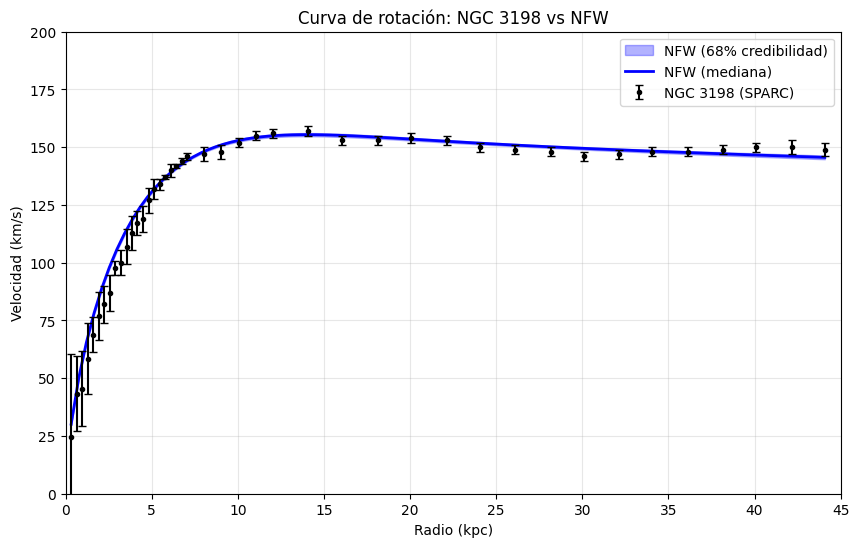

In [ ]:
# ============================================
# CURVA NFW (BURKERT NO CONVERGIO)
# ============================================

plt.figure(figsize=(10, 6))

# Curva NFW con tus samples_sparc
r_fine = np.linspace(r_sparc.min(), r_sparc.max(), 100)
v_samples_nfw = np.array([[v_total(ri, *theta) for ri in r_fine] for theta in samples_sparc[::100]])
v_mean_nfw = np.mean(v_samples_nfw, axis=0)
v_lower_nfw = np.percentile(v_samples_nfw, 16, axis=0)
v_upper_nfw = np.percentile(v_samples_nfw, 84, axis=0)

plt.fill_between(r_fine, v_lower_nfw, v_upper_nfw, alpha=0.3, color='blue', label='NFW (68% credibilidad)')
plt.plot(r_fine, v_mean_nfw, 'b-', label='NFW (mediana)', linewidth=2)

# Datos reales
plt.errorbar(r_sparc, v_sparc, yerr=sigma_sparc, fmt='o', capsize=3,
             color='black', label='NGC 3198 (SPARC)', markersize=3)

plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Curva de rotación: NGC 3198 vs NFW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 45)
plt.ylim(0, 200)
plt.show()

In [79]:
# ============================================
# GENERAR Y EMPAQUETAR RESULTADOS FINALES (CORREGIDO)
# ============================================

import zipfile
import os
import shutil
import matplotlib.pyplot as plt
import corner
import pandas as pd
import numpy as np
from google.colab import files

# ============================================
# LIMPIAR CARPETA ANTERIOR (para evitar duplicados)
# ============================================
if os.path.exists('resultados_finales'):
    shutil.rmtree('resultados_finales')
os.makedirs('resultados_finales', exist_ok=True)

# Configurar estilo
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# ============================================
# FIGURA 1: Corner plot de simulación
# ============================================
fig1 = corner.corner(samples_log, labels=labels_log,
                     truths=[np.log10(M_d_true), R_d_true, np.log10(M_200_true), np.log10(c_true)],
                     quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.savefig('resultados_finales/figura1_corner_simulacion.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 1: corner_simulacion")

# ============================================
# FIGURA 2: Curva de simulación
# ============================================
plt.figure(figsize=(8,5))
plt.fill_between(r_fine, v_lower, v_upper, alpha=0.3, color='blue', label='Región 68%')
plt.plot(r_fine, v_mean, 'b-', label='Ajuste bayesiano', linewidth=2)
plt.errorbar(r_obs, v_obs, yerr=sigma, fmt='o', capsize=3, color='black', label='Datos')
plt.plot(r_obs, v_true, 'r--', label='Verdad', linewidth=2)
plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Curva de rotación - Simulación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('resultados_finales/figura2_curva_simulacion.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 2: curva_simulacion")

# ============================================
# FIGURA 3: Corner plot de SPARC
# ============================================
fig3 = corner.corner(samples_log_sparc, labels=labels_log,
                     quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.savefig('resultados_finales/figura3_corner_sparc.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 3: corner_sparc")

# ============================================
# FIGURA 4: Curva de SPARC
# ============================================
plt.figure(figsize=(8,5))
plt.fill_between(r_fine_sparc, v_lower_sparc, v_upper_sparc, alpha=0.3, color='blue', label='Región 68%')
plt.plot(r_fine_sparc, v_mean_sparc, 'b-', label='Ajuste bayesiano', linewidth=2)
plt.errorbar(r_sparc, v_sparc, yerr=sigma_sparc, fmt='o', capsize=3, color='black', label='NGC 3198 (SPARC)')
plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Curva de rotación - NGC 3198')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('resultados_finales/figura4_curva_sparc.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 4: curva_sparc")

# ============================================
# FIGURA 5: Trazas MCMC de SIMULACIÓN
# ============================================
samples_chain_sim = sampler.get_chain()
fig5, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
colors = plt.cm.rainbow(np.linspace(0, 1, nwalkers))

for i, label in enumerate(labels_log):
    for walker in range(nwalkers):
        axes[i].plot(samples_chain_sim[:, walker, i], alpha=0.5, color=colors[walker], linewidth=0.8)
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].axvline(burnin, color='red', linestyle='--', linewidth=2, label='Burn-in' if i == 0 else '')
    axes[i].grid(True, alpha=0.2)

axes[-1].set_xlabel('Paso', fontsize=12)
plt.suptitle('Trazas MCMC - Simulación (32 walkers)', fontsize=14)
plt.legend(loc='upper right')
plt.savefig('resultados_finales/figura5_trazas_simulacion.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 5: trazas_simulacion")

# ============================================
# FIGURA 6: Trazas MCMC de SPARC
# ============================================
samples_chain_sparc = sampler_sparc.get_chain()
fig6, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, label in enumerate(labels_log):
    for walker in range(nwalkers):
        axes[i].plot(samples_chain_sparc[:, walker, i], alpha=0.5, color=colors[walker], linewidth=0.8)
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].axvline(burnin_sparc, color='red', linestyle='--', linewidth=2, label='Burn-in' if i == 0 else '')
    axes[i].grid(True, alpha=0.2)

axes[-1].set_xlabel('Paso', fontsize=12)
plt.suptitle('Trazas MCMC - NGC 3198 (32 walkers)', fontsize=14)
plt.legend(loc='upper right')
plt.savefig('resultados_finales/figura6_trazas_sparc.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 6: trazas_sparc")

# ============================================
# FIGURA 7.1: Curva NFW (modelo final que sí convergió)
# ============================================
plt.figure(figsize=(8,5))
plt.fill_between(r_fine_sparc, v_lower_sparc, v_upper_sparc, alpha=0.3, color='blue', label='Región de credibilidad 68%')
plt.plot(r_fine_sparc, v_mean_sparc, 'b-', label='Mediana del ajuste NFW', linewidth=2)
plt.errorbar(r_sparc, v_sparc, yerr=sigma_sparc, fmt='o', capsize=3, color='black', label='Datos NGC 3198 (SPARC)', markersize=3)
plt.xlabel('Radio (kpc)')
plt.ylabel('Velocidad (km/s)')
plt.title('Curva de rotación de NGC 3198 - Ajuste NFW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('resultados_finales/figura7.1_nfw.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 7.1: curva_nfw")

# ============================================
# FIGURA 7.2: Comparación NFW vs Burkert (opcional)
# ============================================
figura7_generada = False
try:
    plt.figure(figsize=(8,5))
    plt.fill_between(r_fine_sparc, v_lower_nfw, v_upper_nfw, alpha=0.3, color='blue', label='NFW (68%)')
    plt.plot(r_fine_sparc, v_mean_nfw, 'b-', label='NFW mediana', linewidth=2)
    plt.fill_between(r_fine_sparc, v_lower_burkert, v_upper_burkert, alpha=0.3, color='red', label='Burkert (68%)')
    plt.plot(r_fine_sparc, v_mean_burkert, 'r-', label='Burkert mediana', linewidth=2)
    plt.errorbar(r_sparc, v_sparc, yerr=sigma_sparc, fmt='o', capsize=3, color='black', label='NGC 3198')
    plt.xlabel('Radio (kpc)')
    plt.ylabel('Velocidad (km/s)')
    plt.title('Comparación: NFW vs Burkert')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('resultados_finales/figura7.2_comparacion_nfw_burkert.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("✅ Figura 7.2: comparacion_nfw_burkert")
    figura7_generada = True
except:
    print("⚠️ Figura 7.2 no generada: Burkert no disponible")

# ============================================
# FIGURA 8: Tabla de resultados (SIEMPRE)
# ============================================
plt.figure(figsize=(10, 3))
plt.axis('off')
tabla_data = [
    ['Parámetro', 'Simulación', 'SPARC (NGC 3198)'],
    ['M_d (M_sol)', f'{sim_median[0]:.2e}', f'{sparc_median[0]:.2e}'],
    ['R_d (kpc)', f'{sim_median[1]:.2f}', f'{sparc_median[1]:.2f}'],
    ['M_200 (M_sol)', f'{sim_median[2]:.2e}', f'{sparc_median[2]:.2e}'],
    ['c', f'{sim_median[3]:.2f}', f'{sparc_median[3]:.2f}']
]
plt.table(cellText=tabla_data, loc='center', cellLoc='center')
plt.title('Tabla comparativa de resultados')
plt.savefig('resultados_finales/figura8_tabla_resultados.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figura 8: tabla_resultados")

# ============================================
# TABLAS CSV
# ============================================
df_resultados = pd.DataFrame({
    'Parametro': ['M_d (M_sol)', 'R_d (kpc)', 'M_200 (M_sol)', 'c'],
    'Simulacion_Mediana': sim_median,
    'Simulacion_16%': sim_lower,
    'Simulacion_84%': sim_upper,
    'SPARC_Mediana': sparc_median,
    'SPARC_16%': sparc_lower,
    'SPARC_84%': sparc_upper
})
df_resultados.to_csv('resultados_finales/tabla_resultados.csv', index=False)
print("✅ CSV: tabla_resultados.csv")

df_rhat = pd.DataFrame({
    'Parametro': ['log10(M_d)', 'R_d', 'log10(M_200)', 'log10(c)'],
    'R_hat': rhat
})
df_rhat.to_csv('resultados_finales/rhat_values.csv', index=False)
print("✅ CSV: rhat_values.csv")

# ============================================
# CREAR Y DESCARGAR ZIP (con conteo automático)
# ============================================
zip_name = 'resultados_proyecto.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for root, dirs, files_list in os.walk('resultados_finales'):
        for file in files_list:
            zipf.write(os.path.join(root, file), file)

files.download(zip_name)

# Contar archivos generados
figuras = [f for f in os.listdir('resultados_finales') if f.endswith('.png')]
csvs = [f for f in os.listdir('resultados_finales') if f.endswith('.csv')]

print(f"\n🎉 ZIP descargado: {zip_name}")
print(f"✅ Contiene: {len(figuras)} figuras + {len(csvs)} CSV")
print(f"📁 Archivos: {', '.join(sorted(figuras + csvs))}")

✅ Figura 1: corner_simulacion
✅ Figura 2: curva_simulacion
✅ Figura 3: corner_sparc
✅ Figura 4: curva_sparc


/tmp/ipykernel_18083/740607151.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


✅ Figura 5: trazas_simulacion


/tmp/ipykernel_18083/740607151.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


✅ Figura 6: trazas_sparc
✅ Figura 7.1: curva_nfw
✅ Figura 7.2: comparacion_nfw_burkert
✅ Figura 8: tabla_resultados
✅ CSV: tabla_resultados.csv
✅ CSV: rhat_values.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ZIP descargado: resultados_proyecto.zip
✅ Contiene: 9 figuras + 2 CSV
📁 Archivos: figura1_corner_simulacion.png, figura2_curva_simulacion.png, figura3_corner_sparc.png, figura4_curva_sparc.png, figura5_trazas_simulacion.png, figura6_trazas_sparc.png, figura7.1_nfw.png, figura7.2_comparacion_nfw_burkert.png, figura8_tabla_resultados.png, rhat_values.csv, tabla_resultados.csv
